# **Practical Q2: Decision tree + Random forest**

### Import Libraries

In [2]:
# Improting needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42



---


## Part (a) Load Dataset
### Load Titanic Dataset

In [3]:
from sklearn.datasets import fetch_openml

titanic = fetch_openml("titanic", version=1, as_frame=True)
df = titanic.frame.copy()

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Select Required Columns + Target

In [4]:
FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
TARGET = "survived"

df = df[FEATURES + [TARGET]].copy()

# Make sure target is integer 0/1
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").astype("Int64")

df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0,0,211.3375,S,1
1,1,male,0.9167,1,2,151.5500,S,1
2,1,female,2.0000,1,2,151.5500,S,0
3,1,male,30.0000,1,2,151.5500,S,0
4,1,female,25.0000,1,2,151.5500,S,0


### Quick Data Check (Missing Values)

In [5]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nTarget distribution:\n", df[TARGET].value_counts(dropna=False))

Shape: (1309, 8)

Missing values:
 pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

Target distribution:
 survived
0    809
1    500
Name: count, dtype: Int64


### Train/Test Split (70/30, Stratified, random_state=42)

In [6]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

# Drop rows where target is missing (just in case with OpenML)
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class ratio:\n", y_train.value_counts(normalize=True))
print("\nTest  class ratio:\n", y_test.value_counts(normalize=True))

Train: (916, 7)  Test: (393, 7)

Train class ratio:
 survived
0    0.617904
1    0.382096
Name: proportion, dtype: float64

Test  class ratio:
 survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64


### Preprocessing Pipeline (Impute + OneHot)

In [8]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Fit preprocessing on TRAIN and transform TRAIN/TEST
X_train_arr = preprocess.fit_transform(X_train)
X_test_arr  = preprocess.transform(X_test)

# Get feature names after preprocessing (numeric + onehot)
feature_names = preprocess.get_feature_names_out()

# Convert to DataFrame so we keep column names (needed for feature importance reporting)
X_train_processed = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train.index)
X_test_processed  = pd.DataFrame(X_test_arr,  columns=feature_names, index=X_test.index)

print(X_train_processed.shape, X_test_processed.shape)
X_train_processed.head()

(916, 10) (393, 10)


,num__pclass,num__age,num__sibsp,num__parch,num__fare,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S
306,1.0,54.0,0.0,1.0,77.2875,0.0,1.0,0.0,0.0,1.0
927,3.0,28.0,1.0,0.0,14.4542,0.0,1.0,1.0,0.0,0.0
642,3.0,13.0,4.0,2.0,31.3875,0.0,1.0,0.0,0.0,1.0
1294,3.0,28.5,0.0,0.0,16.1000,0.0,1.0,0.0,0.0,1.0
1015,3.0,55.5,0.0,0.0,8.0500,0.0,1.0,0.0,0.0,1.0




---


# Part B

### Decision Tree: Define Model & Parameter Grid


In [9]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 10, 20]
}

### Decision Tree: GridSearchCV (5-Fold)

In [10]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_grid = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
X_train_prepared = X_train_processed

dt_grid.fit(X_train_processed, y_train)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV Accuracy:", dt_grid.best_score_)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Decision Tree CV Accuracy: 0.8078641007365169


### Decision Tree: Test Evaluation (Accuracy + Confusion Matrix)

Decision Tree Test Accuracy: 0.8295165394402035
Decision Tree Confusion Matrix:
 [[213  30]
 [ 37 113]]


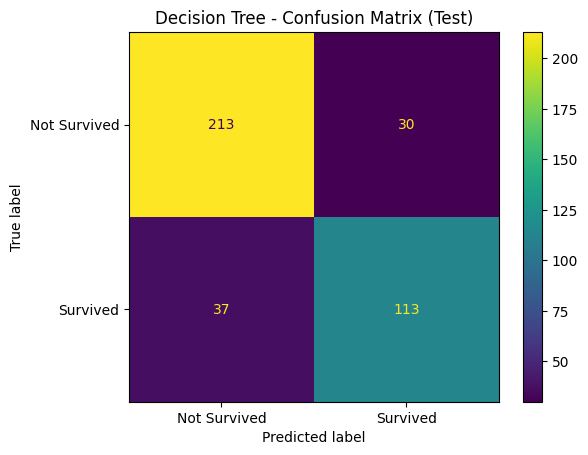

In [11]:
best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test_processed)

dt_test_acc = accuracy_score(y_test, y_pred_dt)
dt_cm = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Test Accuracy:", dt_test_acc)
print("Decision Tree Confusion Matrix:\n", dt_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Not Survived", "Survived"]
)
disp.plot(values_format="d")
plt.title("Decision Tree - Confusion Matrix (Test)")
plt.show()

### Decision Tree: Top-5 Feature Importances

In [12]:
dt_importances = best_dt.feature_importances_

dt_feature_importance_df = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": dt_importances
}).sort_values(by="Importance", ascending=False)

dt_feature_importance_df.head(5)

,Feature,Importance
5,cat__sex_female,0.636851
0,num__pclass,0.175823
2,num__sibsp,0.078638
4,num__fare,0.054621
1,num__age,0.054067




---

# Part C

### Random Forest: Define Model & Parameter Grid

In [13]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [5, None],
    "max_features": ["sqrt"]
}

### Random Forest: GridSearchCV (5-Fold)

In [14]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Random Forest CV Accuracy:", rf_grid.best_score_)

Best Random Forest Params: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 400}
Best Random Forest CV Accuracy: 0.8013186029935853


### Random Forest: Test Evaluation (Accuracy + Confusion Matrix)

Random Forest Test Accuracy: 0.8320610687022901
Random Forest Confusion Matrix:
 [[215  28]
 [ 38 112]]


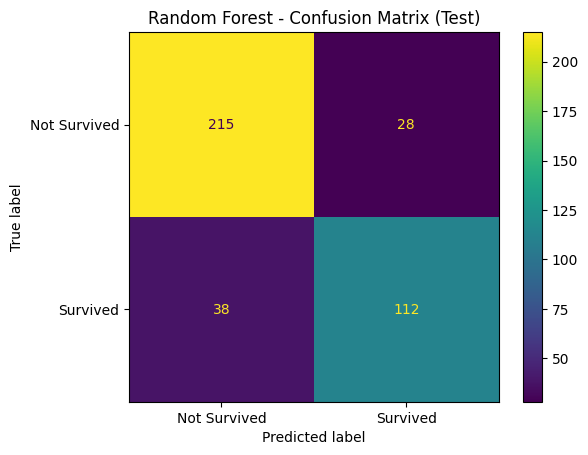

In [15]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test_processed)

rf_test_acc = accuracy_score(y_test, y_pred_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Test Accuracy:", rf_test_acc)
print("Random Forest Confusion Matrix:\n", rf_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Survived", "Survived"]
)
disp.plot(values_format="d")
plt.title("Random Forest - Confusion Matrix (Test)")
plt.show()

### Random Forest: Top-5 Feature Importances

In [16]:
rf_importances = best_rf.feature_importances_

rf_feature_importance_df = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

rf_feature_importance_df.head(5)

,Feature,Importance
6,cat__sex_male,0.278632
5,cat__sex_female,0.265071
4,num__fare,0.136685
0,num__pclass,0.104375
1,num__age,0.094292


### Final Comparison (Decision Tree vs Random Forest)

In [17]:
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test Accuracy": [dt_test_acc, rf_test_acc]
})

comparison_df

,Model,Test Accuracy
0,Decision Tree,0.829517
1,Random Forest,0.832061
